# Anomaly detection and Time Series
## 1. What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.
Anomaly Detection is the process of identifying patterns in data that do not conform to expected behavior. It is useful in identifying outliers or abnormal data points that might indicate problems or unusual events.

Types of Anomalies:

- Point Anomaly: A single data point is significantly different from the rest. For example, a temperature sensor showing 100°C when the normal range is 20-30°C.

- Contextual Anomaly: A data point is considered anomalous within a specific context but normal in others. For instance, a temperature of 30°C might be normal during the summer but anomalous during the winter.

- Collective Anomaly: A group of data points is anomalous when considered together, even if individual points might be normal. For example, a sudden spike in traffic from multiple sources during a normal day could be a collective anomaly indicating a DDoS attack.

## 2. Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.

- Isolation Forest: This algorithm isolates anomalies by randomly selecting a feature and splitting the data. It’s suitable for high-dimensional data and is fast with large datasets.
Use Case: Detecting anomalies in big datasets like financial transactions or network traffic.

- DBSCAN: A density-based algorithm that groups together points with many nearby neighbors and labels points in sparse regions as anomalies. It works well for data with clusters of varying shapes.
Use Case: Identifying spatial anomalies in geospatial data or finding outliers in customer behavior.

- Local Outlier Factor (LOF): LOF measures the local density deviation of a data point with respect to its neighbors. It’s best for detecting anomalies in datasets where local structures matter.
Use Case: Fraud detection in transaction data, where local patterns are important.

## 3. What are the key components of a Time Series? Explain each with one example.

- Trend: The long-term movement in the data (upward or downward). For example, the gradual increase in global temperatures over decades.

- Seasonality: Regular patterns that repeat over time. For instance, retail sales spikes during the holiday season each year.

- Residual (Noise): The random variation in the data after removing trend and seasonality. For example, unexpected fluctuations in stock prices that don’t follow any predictable pattern.

- Cyclic: Longer-term fluctuations (often related to economic cycles) which do not have a fixed period. For example, GDP growth cycles or business cycles.

## 4. Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

- Stationary: A time series is stationary if its statistical properties like mean, variance, and autocorrelation are constant over time. In simple terms, the series doesn’t show trends or seasonality.

- Test for Stationarity: We can use statistical tests like Augmented Dickey-Fuller (ADF) test or Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test to check stationarity.

- Transforming Non-Stationary Series: We can make a non-stationary series stationary by differencing (subtracting the current value from the previous value) or by applying transformations like logarithms or seasonal adjustments. For example, taking the first difference of the series often helps remove trends.

## 5. Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.

- AR (Auto-Regressive): A model where future values are based on a linear combination of past values.
Use Case: Predicting next month’s sales based on previous months' sales data.

- MA (Moving Average): A model that uses past forecast errors to predict future values.
Use Case: Forecasting energy consumption using past errors in predictions.

- ARIMA (Auto-Regressive Integrated Moving Average): Combines AR and MA models along with differencing to make non-stationary data stationary.
Use Case: Forecasting financial market data or stock prices.

- SARIMA (Seasonal ARIMA): A variant of ARIMA that includes seasonal components for modeling seasonality in the data.
Use Case: Modeling monthly air passenger data or retail sales.

- SARIMAX (Seasonal ARIMA with Exogenous Variables): A more advanced version of SARIMA that allows incorporating external factors (like weather) in the model.
Use Case: Predicting energy demand using both historical consumption data and weather conditions.

In [2]:
import gdown
taxi_url = 'https://drive.google.com/uc?id=1NgjnaMX_41yLiutbeM4Dpv6yQdDf82zm'
passengers_url = 'https://drive.google.com/uc?id=1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3'

# Use gdown to download the file
gdown.download(taxi_url, 'NYC_Taxi_Fare.csv', quiet=False)
gdown.download(passengers_url, 'Air_Passengers.csv', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1NgjnaMX_41yLiutbeM4Dpv6yQdDf82zm
From (redirected): https://drive.google.com/uc?id=1NgjnaMX_41yLiutbeM4Dpv6yQdDf82zm&confirm=t&uuid=1e230ad8-0c11-4115-9898-00f1b5070a0d
To: /content/NYC_Taxi_Fare.csv
100%|██████████| 594M/594M [00:07<00:00, 77.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3
To: /content/Air_Passengers.csv
100%|██████████| 1.75k/1.75k [00:00<00:00, 5.11MB/s]


'Air_Passengers.csv'

## 6. Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components

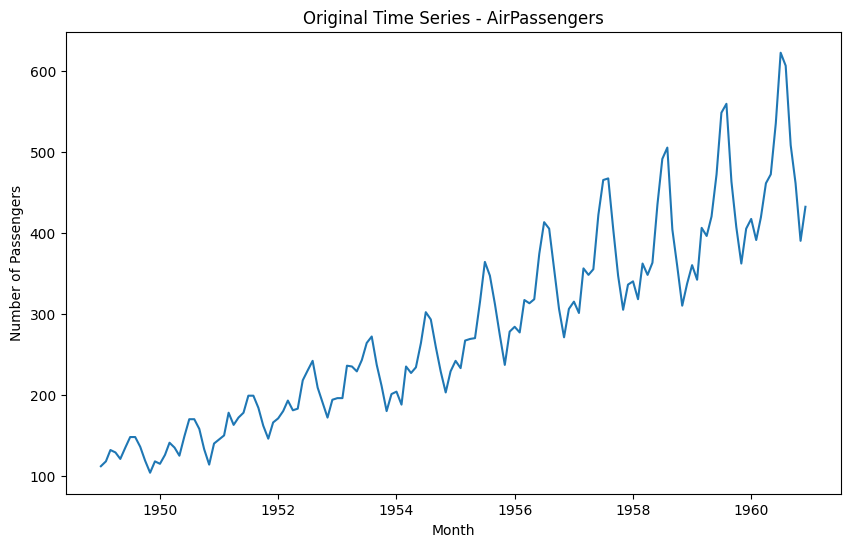

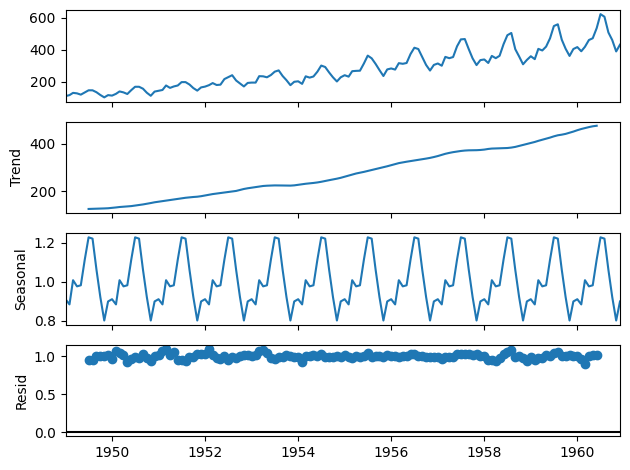

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
data = pd.read_csv('Air_Passengers.csv', parse_dates=['Month'], index_col='Month')

# Plot original series
plt.figure(figsize=(10, 6))
plt.plot(data)
plt.title("Original Time Series - AirPassengers")
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.show()

# Decompose the time series
result = seasonal_decompose(data, model='multiplicative', period=12)
result.plot()
plt.show()

## 7. Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.

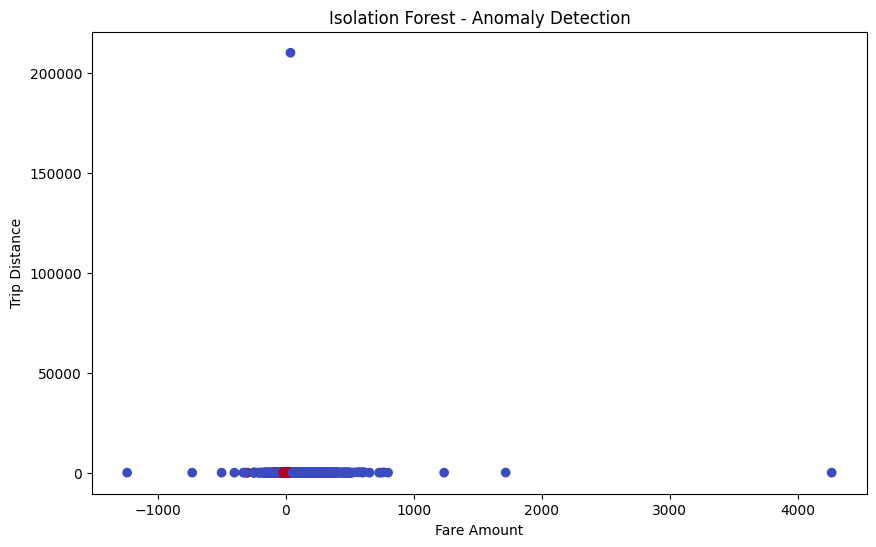

In [ ]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('NYC_Taxi_Fare.csv', low_memory=False)

# Select relevant features for anomaly detection (e.g., fare_amount vs. trip_distance)
X = df[['fare_amount', 'trip_distance']]

# Apply Isolation Forest
model = IsolationForest(contamination=0.05)
df['anomaly'] = model.fit_predict(X)

# Visualize the anomalies
plt.figure(figsize=(10, 6))
plt.scatter(df['fare_amount'], df['trip_distance'], c=df['anomaly'], cmap='coolwarm')
plt.title("Isolation Forest - Anomaly Detection")
plt.xlabel('Fare Amount')
plt.ylabel('Trip Distance')
plt.show()


## 8. Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


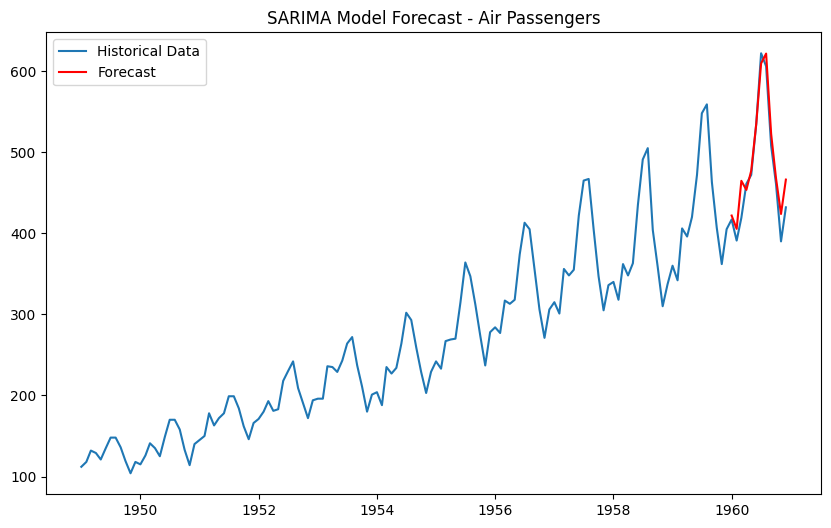

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd



# Read CSV from the URL
data = pd.read_csv('Air_Passengers.csv', parse_dates=['Month'], index_col='Month')
train_data = data[:-12]  # Training data (all but the last 12 months)

# Fit the SARIMA model
model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()

# Forecast the next 12 months
forecast = model_fit.forecast(steps=12)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['#Passengers'], label='Historical Data')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title('SARIMA Model Forecast - Air Passengers')
plt.legend()
plt.show()


## 9. Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


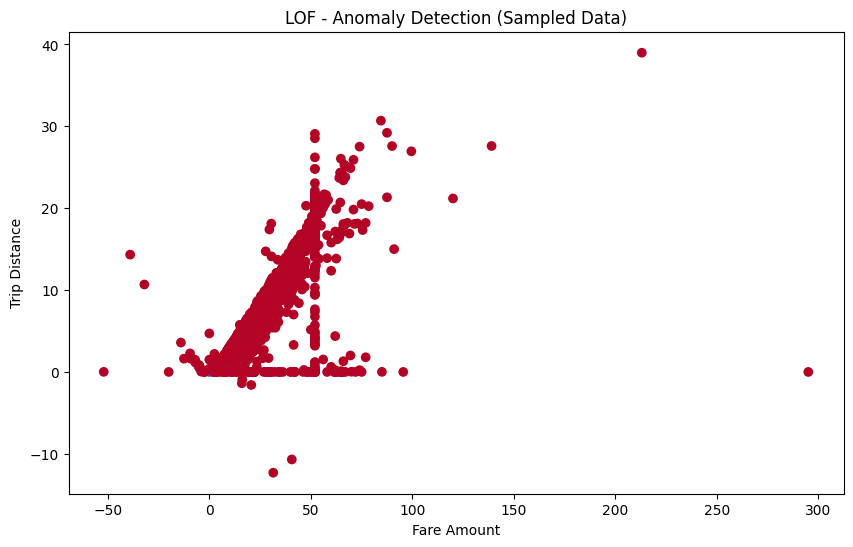

In [3]:
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import pandas as pd

# Read CSV from the URL
# Load dataset
df = pd.read_csv('NYC_Taxi_Fare.csv', low_memory=False)

# Sample a smaller subset (say 10,000 rows) to speed up processing
df_sample = df.sample(n=10000, random_state=42)

# Select relevant features for LOF
X = df_sample[['fare_amount', 'trip_distance']]

# Apply LOF with smaller n_neighbors (default is 20, reduce it if necessary)
lof = LocalOutlierFactor(n_neighbors=10, contamination=0.05)

# Fit the model and predict anomalies
df_sample['anomaly'] = lof.fit_predict(X)

# Visualize the anomalies
plt.figure(figsize=(10, 6))
plt.scatter(df_sample['fare_amount'], df_sample['trip_distance'], c=df_sample['anomaly'], cmap='coolwarm')
plt.title("LOF - Anomaly Detection (Sampled Data)")
plt.xlabel('Fare Amount')
plt.ylabel('Trip Distance')
plt.show()


## 10. You are working as a data scientist for a power grid monitoring company.

Your goal is to forecast energy demand and also detect abnormal spikes or drops in
real-time consumption data collected every 15 minutes. The dataset includes features
like timestamp, region, weather conditions, and energy usage.

Explain your real-time data science workflow:
How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?
- For real-time energy data, I would use Isolation Forest or LOF. These models help detect abnormal spikes or drops in energy consumption, which could be caused by faulty meters, unusual weather conditions, or incorrect data entries.

Which time series model would you use for short-term forecasting (ARIMA /SARIMA / SARIMAX)?

- To predict short-term energy demand, I would use SARIMAX. This model allows for incorporating both historical consumption data and exogenous variables like weather conditions (e.g., temperature, humidity, etc.), which significantly impact energy demand.


How would you validate and monitor the performance over time?
- I would implement a continuous validation mechanism using cross-validation and track performance metrics like Mean Absolute Error (MAE) or Root Mean Squared Error (RMSE). Retraining the model periodically with fresh data will be essential to keep the forecast accuracy high.


How would this solution help business decisions or operations?
- This solution can help the company optimize grid operations by forecasting demand more accurately. Anomalies can signal potential issues in the grid or equipment, enabling early intervention to prevent costly failures. Accurate forecasting and anomaly detection improve the efficiency of energy distribution, reducing costs and helping avoid system overloads.